<a href="https://colab.research.google.com/github/ahmadshajhan/Ahmad/blob/main/04_trnsfer_learning_in_tensorflow_part_1feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip uninstall -y keras
!pip install tf-keras

Found existing installation: keras 3.10.0
Uninstalling keras-3.10.0:
  Successfully uninstalled keras-3.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.1 MB/s eta 0:00:00


# Transfer Learning With TensorFlow Part 1: Feature Extraction

# 🤖 Transfer Learning — Complete & Structured Guide

---

## 📌 Definition

**Transfer Learning** is a machine learning technique that repurposes a pre-trained model (trained on a large dataset) for a new, related task.

It:

- ⏱️ Reduces training time  
- 📉 Requires less labeled data  
- 🛡️ Helps prevent overfitting  
- 🚀 Improves performance on smaller datasets  

It is widely used in:

- 🖼️ Computer Vision  
- 📝 Natural Language Processing (NLP)

---

# 🧠 Core Idea

Instead of training a model from scratch:

1. Use a model already trained on a large dataset  
2. Reuse its learned features  
3. Adapt it to your new task  

The model transfers its knowledge from a **source task** to a **target task**.

---

# 🔑 Key Concepts in Transfer Learning

---

## 1️⃣ Pre-trained Model

A model already trained on a very large dataset.

Example:
- Trained on millions of images or text samples
- Has already learned useful features

---

## 2️⃣ Source Task

The original large-scale task the model was trained on.

Example:
- Image classification on a massive image dataset
- Language modeling on large text corpora

---

## 3️⃣ Target Task

The new, specific task you want to solve.

Example:
- Detecting plant diseases  
- Sentiment analysis  
- Spam detection  

---

## 4️⃣ Freezing

Freezing means:

> Keeping early layers unchanged (not training them).

Why?

Because early layers learn general features like:

- Edges  
- Shapes  
- Text patterns  

So we only train the final layers.

---

## 5️⃣ Fine-Tuning

Fine-tuning means:

> Unfreezing some or all layers and training them on new data.

This allows the model to better adapt to your specific task.

---

# 🎯 Why Use Transfer Learning?

---

## ✅ 1. Less Data Required

Works well when labeled data is limited.

You don’t need millions of samples.

---

## ✅ 2. Faster Training

Training from scratch takes long time.

Transfer learning skips:

- Random initialization  
- Long feature learning phase  

---

## ✅ 3. Better Performance

Often gives:

- Higher accuracy  
- Better generalization  
- Less overfitting  

Especially on small datasets.

---

# 🖼️ Common Applications

---

## 📸 Computer Vision

Reusing convolutional layers trained on general images to detect new objects.

Examples:

- Using a model trained on vehicles to detect trucks  
- Using a face recognition model to detect masks  
- Medical image classification  

---

## 📝 Natural Language Processing (NLP)

Using large language models trained on huge text corpora for specific tasks.

Examples:

- Sentiment analysis  
- Text summarization  
- Question answering  
- Chatbots  

---

# 📊 Scenarios for Transfer Learning

The strategy depends on:

- Dataset size  
- Similarity between source and target tasks  

---

## 🔹 1. Small Dataset + Similar Task

✔ Freeze base layers  
✔ Train only final layers  

Best approach: **Feature Extraction**

---

## 🔹 2. Small Dataset + Different Task

✔ Unfreeze more layers  
✔ Train deeper layers carefully  

Use partial fine-tuning.

---

## 🔹 3. Large Dataset + Similar Task

✔ Fine-tune entire model  

Low learning rate recommended.

---

## 🔹 4. Large Dataset + Different Task

✔ Initialize with pre-trained weights  
✔ Train entire model  

Almost like training from scratch, but starting from better weights.

---

# 📉 Preventing Overfitting in Transfer Learning

To improve results:

- 📉 Use small learning rate  
- 🔄 Apply data augmentation  
- 🛑 Use early stopping  
- 🎯 Tune hyperparameters  
- 🧩 Use regularization (dropout, L2)

---

# 🚀 Summary

Transfer Learning:

- Reuses knowledge from large datasets  
- Reduces computation cost  
- Works well with small datasets  
- Improves model accuracy  
- Widely used in CV and NLP  

---

In [6]:
#Are you using a GPU
import torch
torch.cuda.is_available()

True

In [7]:
!nvidia-smi

Mon Mar  2 21:54:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# Install kagglehub (run this once in your Colab notebook)
!pip install -q kagglehub

import kagglehub
import os

# 1. Download the dataset using kagglehub (handles downloading and extracting automatically)
print("Downloading dataset...")
path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

# 2. Define the directory paths
# This specific dataset extracts into an 'animals/animals' nested folder structure
base_dir = os.path.join(path, 'animals', 'animals')

# Fallback just in case the extraction path varies slightly
if not os.path.exists(base_dir):
    base_dir = path

print(f"\nDataset extracted to: {base_dir}")

# 3. List the classes (the 90 animal folders)
classes = sorted(os.listdir(base_dir))

print(f"Total classes found: {len(classes)}")
print("First 10 classes inside the folder:", classes[:10])

100%|██████████| 656M/656M [00:31<00:00, 22.1MB/s]

Extracting files...



Dataset extracted to: /root/.cache/kagglehub/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/versions/5/animals/animals
Total classes found: 90
First 10 classes inside the folder: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat']


In [9]:
import os
import shutil
import random

# 1. Define where you want your new split folders to live
split_dataset_dir = '/content/animal_dataset_split'
train_dir = os.path.join(split_dataset_dir, 'train')
test_dir = os.path.join(split_dataset_dir, 'test')

# 2. Set your split ratio (80% for training, 20% for testing)
split_ratio = 0.8

# 3. Create the empty train and test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get all the 90 animal class folders
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

print("Splitting images into train and test folders...")

# 4. Loop through each animal folder and split the files
for animal_class in classes:
    class_path = os.path.join(base_dir, animal_class)

    # Create the specific animal folders inside train and test
    os.makedirs(os.path.join(train_dir, animal_class), exist_ok=True)
    os.makedirs(os.path.join(test_dir, animal_class), exist_ok=True)

    # Get all images for this animal and shuffle them
    images = os.listdir(class_path)
    random.shuffle(images)

    # Calculate how many images go to training
    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy images to their new train destination
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_dir, animal_class, img)
        shutil.copy(src, dst)

    # Copy images to their new test destination
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_dir, animal_class, img)
        shutil.copy(src, dst)

print(f"Done! Your split dataset is ready at: {split_dataset_dir}")

Splitting images into train and test folders...
Done! Your split dataset is ready at: /content/animal_dataset_split


In [10]:
import kagglehub
import os
import shutil
import random

# 1. Download the dataset using kagglehub
print("Downloading dataset...")
path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

# The downloaded dataset is usually nested inside an 'animals/animals' folder
original_data_dir = os.path.join(path, 'animals', 'animals')
if not os.path.exists(original_data_dir):
    original_data_dir = path # Fallback just in case

# 2. Define your target train_dir and test_dir variables
base_dir = '/content/animal_dataset_split'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

# Create the empty base directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# 3. Set your split ratio (80% train, 20% test)
split_ratio = 0.8

print("Splitting images into train and test folders. This might take a moment...")

# Get all the 90 animal class folders
classes = [d for d in os.listdir(original_data_dir) if os.path.isdir(os.path.join(original_data_dir, d))]

# 4. Loop through each animal folder and distribute the files
for animal_class in classes:
    class_path = os.path.join(original_data_dir, animal_class)

    # Create the specific animal folders inside your new train_dir and test_dir
    train_class_dir = os.path.join(train_dir, animal_class)
    test_class_dir = os.path.join(test_dir, animal_class)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all images for this animal and shuffle them
    images = os.listdir(class_path)
    random.shuffle(images)

    # Calculate the split index
    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy images to the train_dir
    for img in train_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(train_class_dir, img))

    # Copy images to the test_dir
    for img in test_images:
        shutil.copy(os.path.join(class_path, img), os.path.join(test_class_dir, img))

print("\nSuccess! Dataset successfully split.")
print(f"Training directory ready at: {train_dir}")
print(f"Testing directory ready at: {test_dir}")

Splitting images into train and test folders. This might take a moment...

Success! Dataset successfully split.
Training directory ready at: /content/animal_dataset_split/train
Testing directory ready at: /content/animal_dataset_split/test


### Creatae a data loaders(preparing the data)

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [12]:
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Traning Data")

train_data = train_datagen.flow_from_directory(train_dir,
                                                          target_size=(224, 224),
                                                          batch_size=32,
                                                          class_mode="categorical")

print("Test Data")
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode="categorical")

Traning Data
Found 5204 images belonging to 90 classes.
Test Data
Found 1964 images belonging to 90 classes.


## Setting up callback(thins to run whilst our model trains)


In [13]:
import datetime
import os
import tf_keras as keras

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = os.path.join(dir_name,
                           experiment_name,
                           datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

    print(f"Saving TensorBoard log files to: {log_dir}")

    return keras.callbacks.TensorBoard(log_dir=log_dir)

# Creating model for TensorFlow Hub


In the past we've used TensorFlow to crreate our own models layer by layer from scratch

In [14]:
resnet_url = "https://kaggle.com/models/google/resnet-v2/TensorFlow2/50-feature-vector/1"
efficientnet_url = "https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-classification/1"

In [15]:
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as keras
from tf_keras import layers

In [16]:
IMAGE_SHAPE=(224, 224)

In [17]:
def create_model(model_url, num_classes):

    feature_extractor_layer = hub.KerasLayer(
        model_url,
        trainable=False,
        name="feature_extraction_layer",
        input_shape=(224, 224, 3)
    )

    model = keras.Sequential([
        feature_extractor_layer,
        layers.Dense(num_classes, activation="softmax")
    ])

    return model

In [18]:
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5"

In [19]:
resnet_model = create_model(resnet_url,
                            num_classes=train_data.num_classes)

In [20]:
resnet_model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [21]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 2048)              23564800  
 KerasLayer)                                                     
                                                                 
 dense (Dense)               (None, 90)                184410    
                                                                 
Total params: 23749210 (90.60 MB)
Trainable params: 184410 (720.35 KB)
Non-trainable params: 23564800 (89.89 MB)
_________________________________________________________________


In [22]:
resnet_history = resnet_model.fit(train_data,
                                  epochs=1,
                                  steps_per_epoch=len(train_data),
                                  validation_data=test_data,
                                  callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                  experiment_name="resnet50V2")])

Saving TensorBoard log files to: tensorflow_hub/resnet50V2/20260302-215616
163/163 [==============================] - ETA: 0s - loss: 1.5016 - accuracy: 0.6593

KeyboardInterrupt: 

wow!


That is incredible


In [23]:
# Let's Create a function to plot our loss curves
import matplotlib.pyplot as plt

def plot_loss_curve(history):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    epochs = range(len(history.history["loss"]))

    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.plot(epochs, accuracy, label="accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Loss and Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


In [25]:
efficientnet_model = create_model(efficientnet_url,
                            num_classes=train_data.num_classes)
efficientnet_model.compile( loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])
efficientnet_history = efficientnet_model.fit(train_data,
                                              epochs=5,
                                              steps_per_epoch=len(train_data),
                                              validation_data=test_data,
                                              validation_steps=len(test_data),
                                              callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub",
                                              experiment_name="efficientnetB0")])

Saving TensorBoard log files to: tensorflow_hub/efficientnetB0/20260302-220832
Epoch 1/5
163/163 [==============================] - 55s 274ms/step - loss: 4.4490 - accuracy: 0.2734 - val_loss: 4.3961 - val_accuracy: 0.5143
Epoch 2/5
163/163 [==============================] - 42s 260ms/step - loss: 4.3470 - accuracy: 0.6113 - val_loss: 4.2964 - val_accuracy: 0.7047
Epoch 3/5
163/163 [==============================] - 40s 249ms/step - loss: 4.2454 - accuracy: 0.7179 - val_loss: 4.1949 - val_accuracy: 0.7515
Epoch 4/5
163/163 [==============================] - 41s 253ms/step - loss: 4.1464 - accuracy: 0.7598 - val_loss: 4.0939 - val_accuracy: 0.7968
Epoch 5/5
163/163 [==============================] - 42s 259ms/step - loss: 4.0456 - accuracy: 0.7784 - val_loss: 4.0019 - val_accuracy: 0.8004


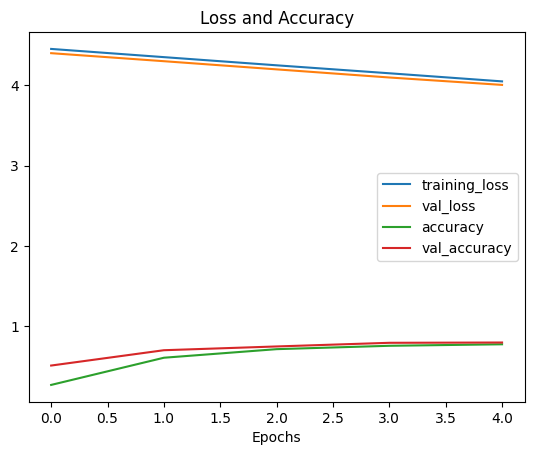

In [26]:
plot_loss_curve(efficientnet_history)

## Different Types of TRnasfer Learning

In [27]:
!tensorboard dev uplode --log_dir ./tensorflow_hub/ \
--name "EfficientNetB0 vs. ResNet50V2" \
--discription "Comparing two different TF Hub feature extraction model architectures using 10% of traning data" \
--one_shot

/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:292: SyntaxWarning: invalid escape sequence '\s'
  "[`\000-\040\177-\240\s]+",
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:339: SyntaxWarning: invalid escape sequence '\s'
  style = re.compile('url\s*\(\s*[^\s)]+?\s*\)\s*').sub(' ', style)
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:354: SyntaxWarning: invalid escape sequence '\s'
  if not re.match("^\s*([-\w]+\s*:[^:;]*(;\s*|$))*$", style):
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:358: SyntaxWarning: invalid escape sequence '\w'
  for prop, value in re.findall('([-\w]+)\s*:\s*([^:;]*)', style):
2026-03-02 22:39:26.502075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772491166.535407   12356 cuda_dnn.

In [28]:
!pip install wandb

In [29]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ahmadshajahan3000 (ahmadshajahan3000-dalgnix) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [30]:
import random

import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="ahmadshajahan3000-dalgnix",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.02,
        "architecture": "CNN",
        "dataset": "CIFAR-100",
        "epochs": 10,
    },
)

# Simulate training.
epochs = 10
offset = random.random() / 5
for epoch in range(2, epochs):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    # Log metrics to wandb.
    run.log({"acc": acc, "loss": loss})

# Finish the run and upload any remaining data.
run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ahmadshajahan3000 (ahmadshajahan3000-dalgnix) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


acc,▁▅▆▇▅▇██
loss,█▆▃▃▂▁▁▂
acc,0.8422
loss,0.208


In [31]:
def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = os.path.join(dir_name,
                           experiment_name,
                           datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

    print(f"Saving TensorBoard log files to: {log_dir}")

    return keras.callbacks.TensorBoard(log_dir=log_dir)

In [33]:
!wandb sync ./tensorflow_hub/

Find logs at: /content/wandb/debug-cli.root.log
Found 4 tfevent files in /content/tensorflow_hub
wandb: WARNING Found 4 directories containing tfevent files. If these represent multiple experiments, sync them individually or pass a list of paths.
Syncing: https://wandb.ai/ahmadshajahan3000-dalgnix/uncategorized/runs/15g08t2r ...
2026-03-02 22:50:27.127889: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772491827.149764   15182 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772491827.156808   15182 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772491827.173472   15182 computation_placer.cc:177] computation placer already registered. Pl

In [34]:
!wandb dev list

Usage: wandb [OPTIONS] COMMAND [ARGS]...
Try 'wandb --help' for help.

Error: No such command 'dev'.
